In [1]:
import numpy as np
import pandas as pd
import your
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
import matplotlib as mpl
from matplotlib import colors
from scipy.optimize import curve_fit, leastsq
import numpy.ma as ma
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator

from typing import Union, List

import frb_functions

In [2]:
def flipped_gaus(x, a, x0, sigma, d):
    return -a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + d

def gaus(x, a, x0, sigma, d):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + d

In [3]:
def sn_vs_dm_1peak(csv, obs, burst_code, tsamp, fsamp, csv_save_bool=False):

    df = pd.read_csv(csv, sep=",", header=0, index_col=0)
    
    sn_filter = df["sn_peak"].values
    dm_filter = df["DM"].values 
    print(f"Number of DM-steps used in fits: {len(dm_filter)}")
    
    poptc,pcovc=curve_fit(gaus, dm_filter, sn_filter, p0=[150,528.8 ,0.5,15], maxfev=10000)
    best_dm = poptc[1]
    a, dm0, sigma, d = poptc
    peak_sn = gaus(best_dm, *poptc)

    print(f"Best DM from Gaussian fit: {best_dm:.3f} pc/cc")
    print(f"Peak S/N from fit: {peak_sn:.3f}")

    # --- Analytic DM error from S/N - 1 method ---
    def dm_error_for_drop(sn_drop):
        sn_target = peak_sn - sn_drop
        val = (sn_target - d) / a
        delta_dm = sigma * np.sqrt(-2 * np.log(val))
        return delta_dm

    dm_err_1 = dm_error_for_drop(1)
    dm_err_3 = dm_error_for_drop(3)

    dm_right_1 = best_dm + dm_err_1
    dm_left_1  = best_dm - dm_err_1
    dm_right_3 = best_dm + dm_err_3
    dm_left_3  = best_dm - dm_err_3

    print(f"S/N-1 DM error: +/-{dm_err_1:.3f} pc/cm^3")
    print(f"S/N-3 DM error: +/-{dm_err_3:.3f} pc/cm^3")

    sigma_3_err = 3*poptc[2]/np.sqrt(len(dm_filter))
    print(f'OLD METHOD : best dm from Gaussian fit: {best_dm:.3f} +- {sigma_3_err:.3f} pc/cc')

    df = pd.read_csv(csv, sep=",", header=0, index_col=0)
    sn_range = df["sn_peak"].values 
    dm_range = df["DM"].values 

    high_idx_dm = dm_range[np.argmax(sn_range)]
    print(f"DM value with the highest SN: {high_idx_dm:.3f} pc/cc")

    fig, ax = plt.subplots(figsize=(8,8))
    
    plt.scatter(dm_range, sn_range, color='k', ls='-')
    
    dm_space = np.linspace(dm_filter[0], dm_filter[-1], 10000)
    plt.plot(dm_space, gaus(dm_space, *poptc), color='#5e3c99', lw=5)
    
    plt.axvline(best_dm, color="#e66101", lw=2)    

    # # S/N-3 span (outer, lighter)
    # plt.axvspan(xmin=dm_left_3, xmax=dm_right_3, color='darkorange', alpha=0.15, label=r"S/N $-$ 3")
    plt.axvline(dm_left_3,  color='darkorange', lw=2, ls=':')
    plt.axvline(dm_right_3, color='darkorange', lw=2, ls=':')

    # S/N-1 span (inner, darker)
    plt.axvspan(xmin=dm_left_1, xmax=dm_right_1, color='darkorange', alpha=0.35, label=r"S/N $-$ 1")
    plt.axvline(dm_left_1,  color='blue', lw=2, ls='--')
    plt.axvline(dm_right_1, color='blue', lw=2, ls='--')

    #plt.legend(fontsize=14, loc='upper left')
    
    plt.xlabel(r'DM (pc cm$^{-3})$', size=25)
    plt.ylabel('S/N', size=25)
    dm = best_dm
    offset = 2.0
    plt.xlim(dm-offset, dm+offset)

    ax.text(0.96, 0.96, f"{burst_code}", transform=ax.transAxes, fontsize=18, va='top', ha='right')   

    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1.5)
        ax.tick_params(axis='both', which='major', labelsize=15, width=1.5, length=8)
        ax.tick_params(axis='both', which='minor', labelsize=15, width=1, length=5)

    plt.grid(which="both", alpha=0.2)

    ax.text(0.04, 0.96,
            fr"$\Delta$t  = {(tsamp):.0f} $\mu$s" + "\n" +
            fr"$\Delta \nu$  = {(fsamp):.0f} kHz" + "\n" +
            fr"DM = {best_dm:.3f}" + "\n" +
            r"$\pm$ " + fr"{np.abs(dm_err_1):.3f} (S/N$-$1)" + r" pc cm$^{-3}$" + "\n" +
            r"$\pm$ " + fr"{np.abs(dm_err_3):.3f} (S/N$-$3)" + r" pc cm$^{-3}$",
            transform=ax.transAxes, fontsize=16, va='top', ha='left')

    plt.show()

    if csv_save_bool == True:
        start_dm = np.min(dm_range)
        stop_dm = np.max(dm_range)
        dmstep = dm_range[1] - dm_range[0]
        csv_name = f"{obs}_{start_dm}_{stop_dm}_{dmstep:.4f}_{len(dm_filter)}steps_{tsamp}us_{fsamp}khz.csv"
        print(f"csv name: {csv_name}")
        df.to_csv(csv_name, sep=",", header=True, index=True)

    plot_name = f"{burst_code}_{tsamp}us_{fsamp}MHz_{len(dm_filter)}steps"
    print(f"saving:{plot_name}")
    fig.savefig(plot_name + ".pdf", dpi=300, bbox_inches='tight')
    fig.savefig(plot_name + ".png", facecolor='white',
                transparent=False, format='png', bbox_inches='tight', dpi=300)
        
    return

# sn_vs_dm_1peak("peak_sn.csv", obs="p47024_24_part2", burst_code="test",
#                tsamp=64, fsamp=500, csv_save_bool=False)

Number of DM-steps used in fits: 83
Best DM from Gaussian fit: 528.904 pc/cc
Peak S/N from fit: 136.933
S/N-1 DM error: +/-0.139 pc/cm^3
S/N-3 DM error: +/-0.242 pc/cm^3
OLD METHOD : best dm from Gaussian fit: 528.904 +- 0.292 pc/cc
DM value with the highest SN: 528.840 pc/cc


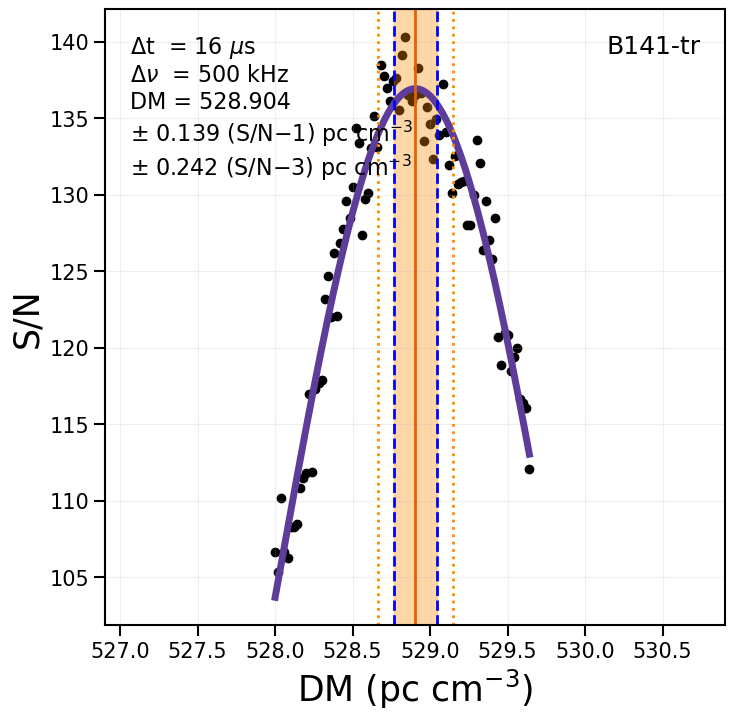

saving:B141-tr_16us_500MHz_83steps


In [5]:
sn_vs_dm_1peak("/home/omar/git/r147-single-dish-analysis/dm_opt_loop/rn1l62_14/rn1l62_14_528.0_530.0_0.0200_70steps_8us_500khz.csv",\
               obs="rn1l62_14", burst_code="B141-tr", \
               tsamp=16, fsamp=500, csv_save_bool=False)

Number of DM-steps used in fits: 201
Best DM from Gaussian fit: 528.468 pc/cc
Peak S/N from fit: 79.060
S/N-1 DM error: +/-0.081 pc/cm^3
S/N-3 DM error: +/-0.142 pc/cm^3
OLD METHOD : best dm from Gaussian fit: 528.468 +- 0.086 pc/cc
DM value with the highest SN: 528.530 pc/cc


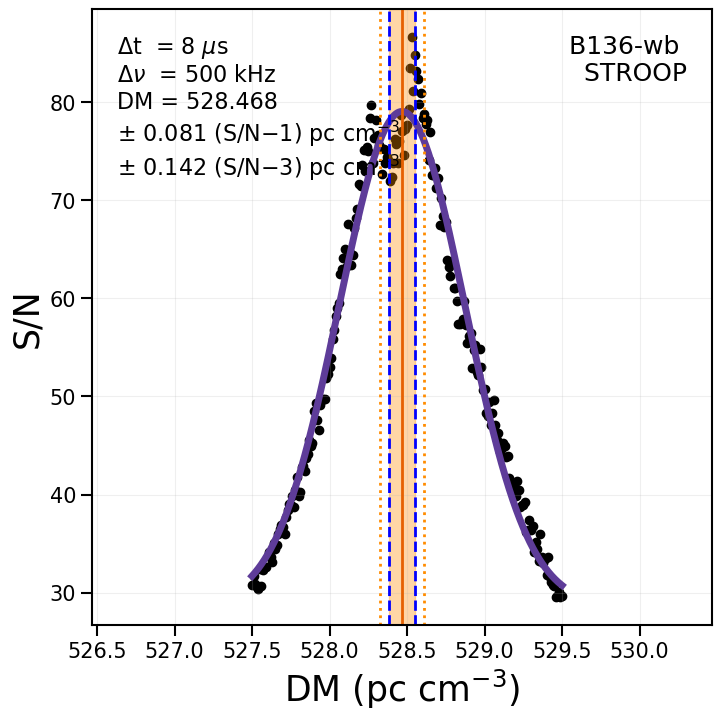

saving:B136-wb 
 STROOP_8us_500MHz_201steps


In [6]:
sn_vs_dm_1peak("/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p55097_41/p55097_41_527.5_529.5_0.0100_201steps_8us_500khz.csv",\
               obs="p55097_41", burst_code="B136-wb \n STROOP", \
               tsamp=8, fsamp=500, csv_save_bool=False)

Number of DM-steps used in fits: 81
Best DM from Gaussian fit: 528.461 pc/cc
Peak S/N from fit: 21.095
S/N-1 DM error: +/-0.087 pc/cm^3
S/N-3 DM error: +/-0.158 pc/cm^3
OLD METHOD : best dm from Gaussian fit: 528.461 +- 0.071 pc/cc
DM value with the highest SN: 528.400 pc/cc


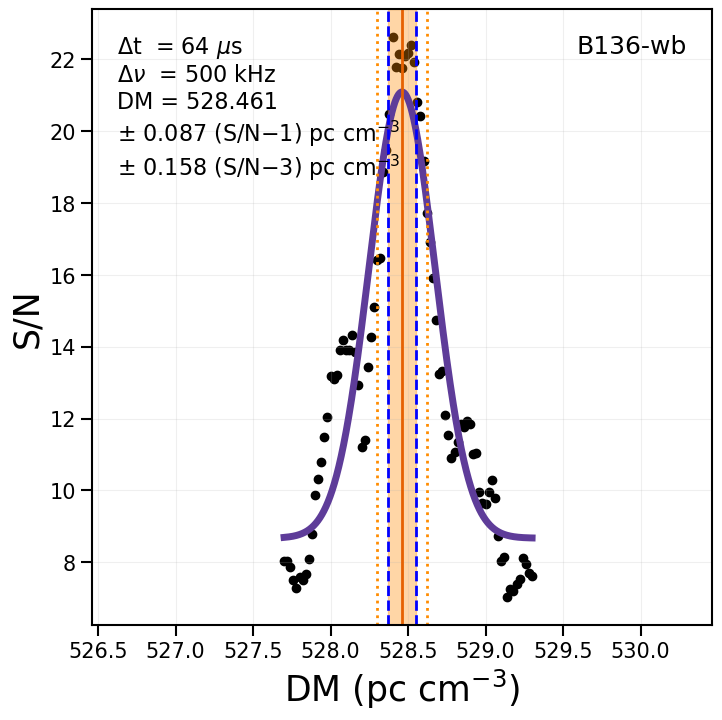

saving:B136-wb_64us_500MHz_81steps


In [7]:
sn_vs_dm_1peak("/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p55092_32/p55092_32_527.7_529.3_0.0200_81steps_64us_500khz.csv",\
               obs="p55092_32", burst_code="B136-wb", \
               tsamp=64, fsamp=500, csv_save_bool=False)

Number of DM-steps used in fits: 78
Best DM from Gaussian fit: 528.195 pc/cc
Peak S/N from fit: 73.460
S/N-1 DM error: +/-0.267 pc/cm^3
S/N-3 DM error: +/-0.463 pc/cm^3
OLD METHOD : best dm from Gaussian fit: 528.195 +- 7.168 pc/cc
DM value with the highest SN: 528.300 pc/cc


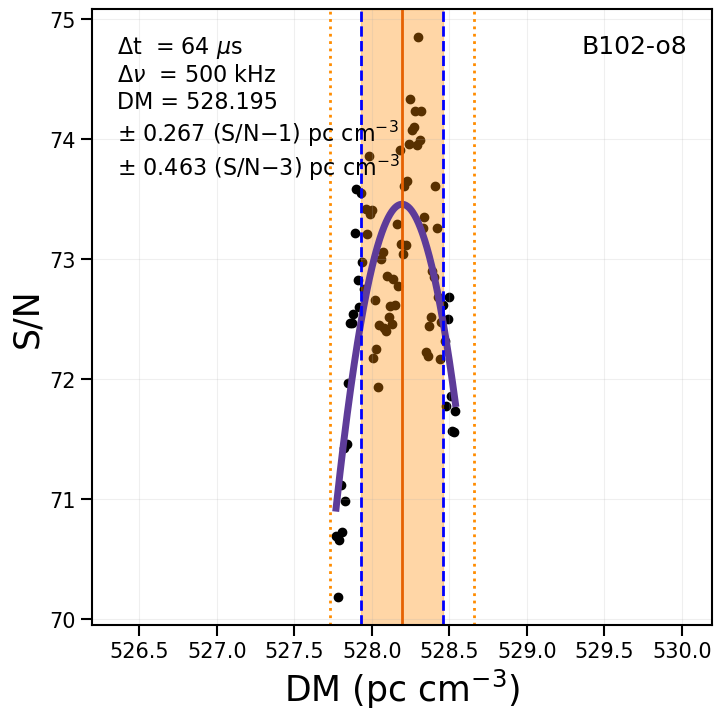

saving:B102-o8_64us_500MHz_78steps


In [8]:
sn_vs_dm_1peak("/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p47027_10/p47027_10_526.7_529.7_0.0100_149steps_64us_500khz.csv",\
               obs="p47027_10", burst_code="B102-o8", \
               tsamp=64, fsamp=500, csv_save_bool=False)

Number of DM-steps used in fits: 41
Best DM from Gaussian fit: 529.040 pc/cc
Peak S/N from fit: 76.898
S/N-1 DM error: +/-nan pc/cm^3
S/N-3 DM error: +/-nan pc/cm^3
OLD METHOD : best dm from Gaussian fit: 529.040 +- -0.100 pc/cc
DM value with the highest SN: 528.100 pc/cc


/tmp/ipykernel_3091359/2693610465.py:21: RuntimeWarning: invalid value encountered in sqrt
  delta_dm = sigma * np.sqrt(-2 * np.log(val))


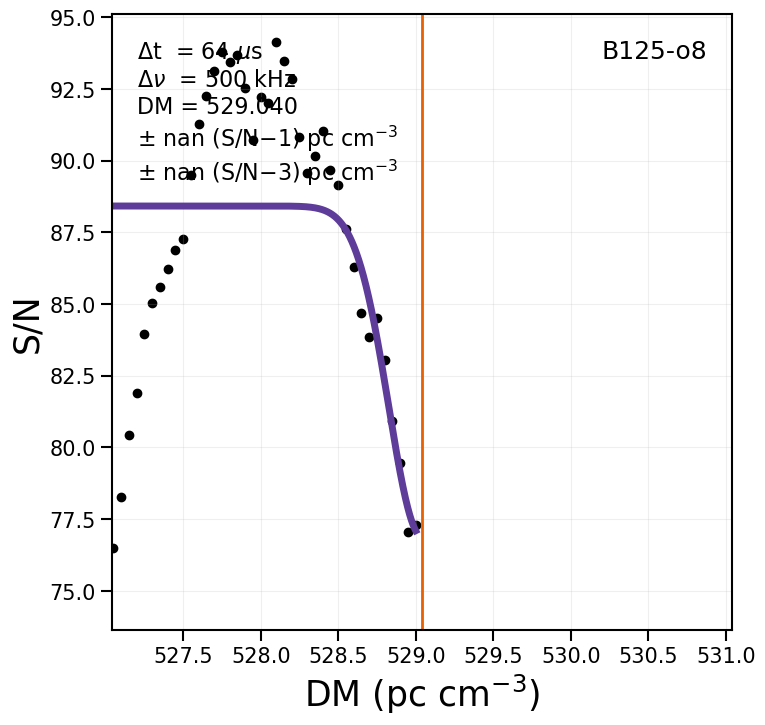

saving:B125-o8_64us_500MHz_41steps


In [9]:
sn_vs_dm_1peak("/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p47064_38/p47064_38_527.0_529.0_0.0500_41steps_64us_500khz.csv",\
               obs="p47064_38", burst_code="B125-o8", \
               tsamp=64, fsamp=500, csv_save_bool=False)

Number of DM-steps used in fits: 50
Best DM from Gaussian fit: 528.146 pc/cc
Peak S/N from fit: 54.317
S/N-1 DM error: +/-0.160 pc/cm^3
S/N-3 DM error: +/-0.335 pc/cm^3
OLD METHOD : best dm from Gaussian fit: 528.146 +- 0.095 pc/cc
DM value with the highest SN: 528.140 pc/cc


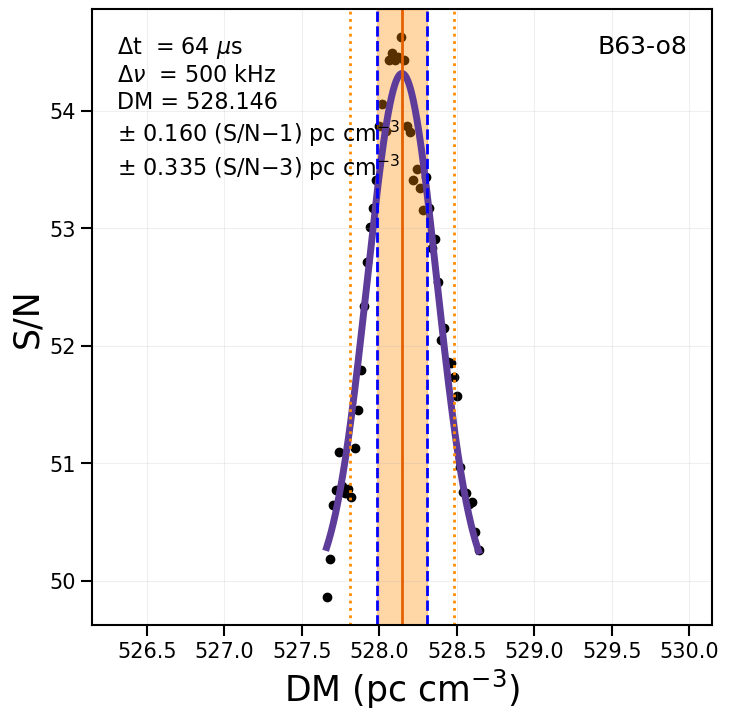

saving:B63-o8_64us_500MHz_50steps


In [10]:
sn_vs_dm_1peak("/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p47024_24/p47024_24_527.0_529.2_0.0200_111steps_64us_500khz.csv",\
               obs="p47024_24", burst_code="B63-o8", \
               tsamp=64, fsamp=500, csv_save_bool=False)

Number of DM-steps used in fits: 71
Best DM from Gaussian fit: 527.854 pc/cc
Peak S/N from fit: 15.431
S/N-1 DM error: +/-0.075 pc/cm^3
S/N-3 DM error: +/-0.142 pc/cm^3
OLD METHOD : best dm from Gaussian fit: 527.854 +- 0.052 pc/cc
DM value with the highest SN: 527.910 pc/cc


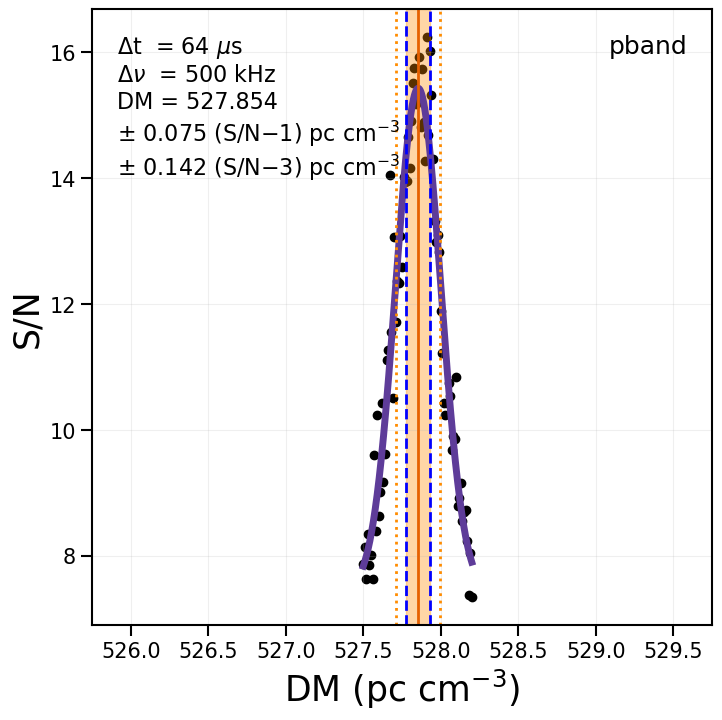

saving:pband_64us_500MHz_71steps


In [35]:
sn_vs_dm_1peak("/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p47030_21/p47030_21_527.5_528.9_0.0100_85steps_32us_500khz.csv",\
               obs="test", burst_code="pband", \
               tsamp=64, fsamp=500, csv_save_bool=False)

Number of DM-steps used in fits: 78
Best DM from Gaussian fit: 527.830 pc/cc
Peak S/N from fit: 143.110
S/N-1 DM error: +/-0.102 pc/cm^3
S/N-3 DM error: +/-0.186 pc/cm^3
OLD METHOD : best dm from Gaussian fit: 527.830 +- 0.083 pc/cc
DM value with the highest SN: 527.770 pc/cc


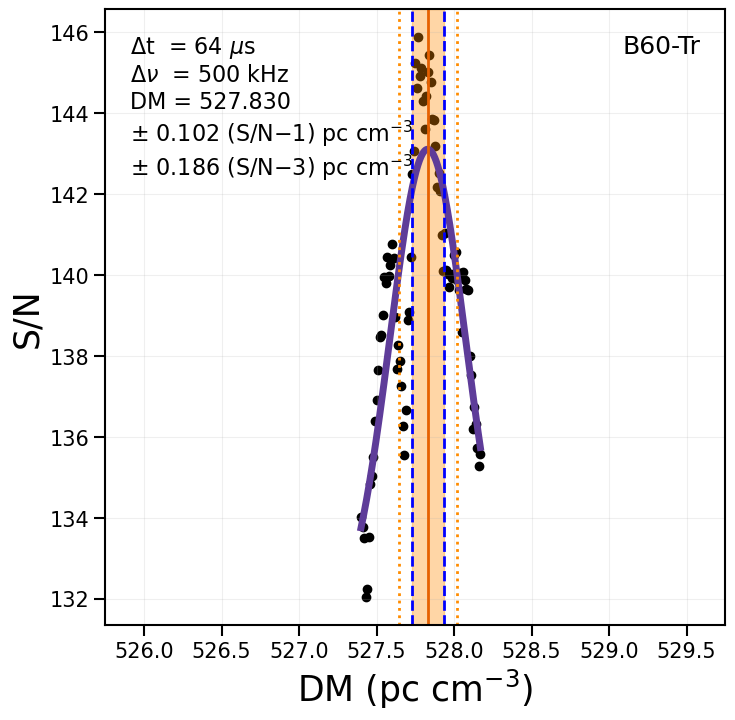

saving:B60-Tr_64us_500MHz_78steps


In [36]:
sn_vs_dm_1peak("/home/omar/git/r147-single-dish-analysis/dm_opt_loop/rn1l10_11/rn1l10_11_part2_527.4_529.0_0.0100_80steps_64us_500khz.csv",\
               obs="test", burst_code="B60-Tr", \
               tsamp=64, fsamp=500, csv_save_bool=False)